# Let's Build an Agent from Scratch!



---


**VERSION HISTORY - DON'T DELETE**

* V6.0 - **March 5, 2026** - Rama Ramakrishnan
  * Google Search API was erroring out so replaced it with Wikipedia search API.
  * Fixed parsing of Wikipedia search result JSON.
  * Tweaked the ReAct prompt to "encourage" tool use.
  * Refreshed the examples
* V5.0 - March 9, 2025 - Removed Wikipedia tool; Fixed date bug and search tool reference in system prompt - Rama Ramakrishnan
* V4.0 - March 9, 2025 - Added Google Search tool; use GPT 4o so updated prompts - Vivek Farias
* V3.0 - March 9, 2025 - Replaced OOP code completely with functional code, added more explanatory notes - Rama Ramakrishnan
* V2.0 - March 7, 2025 - "Robustified" the system prompt, added examples - Rama Ramakrishnan
* V1.0 - March 6, 2025 - Initial attempt - Rama Ramakrishnan

(if you notice errors, please email ramar@mit.edu)


*Note to HODL teaching team*: To make edits or run the colab, please do it on a copy (File > Save a copy in Drive).

---



**CREDIT**: Substantially modified and extended version of https://til.simonwillison.net/llms/python-react-pattern

## Introduction
There are lots of software frameworks for building agents. But since they obscure a lot of the details, they are not ideal for **really** understanding what's going on.

To learn the key ideas, there's nothing better than building one yourself from scratch. In this colab, we will use just basic Python code to give `GPT-4.1-mini` agentic superpowers 🚀!



---

Here is the overall plan for transforming `GPT-4.1-mini` into an Agent.

1. We will create three **tools**. As we saw in lecture, you can think of a tool as just a **function**. So, we will define three Python functions to do the following:
  * calculate something
  * search Wikipedia
  * fetch a weather forecast

2. We will design a prompt that "teaches" `GPT-4.1-mini` how and when to use these functions. To do so, we will use a simplified version of a popular Agentic framework called ReAct ([academic paper](https://arxiv.org/abs/2210.03629)).

3. We will write some basic code to assemble the prompt and the functions into an `ask_the_agent` function (similar to the `ask_the_LLM` function from the Lecture 10 "How to use the LLM API" colab).


---



## Setup

In [ ]:
from google.colab import userdata

from openai import OpenAI
client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))
GPT_MODEL = "gpt-4.1-mini"

## Function Definitions

### A calculator funcion

To evaluate any arithmetic expression written in Python syntax, the `eval` function is very handy. For example:

In [ ]:
eval('23 * 45')

1035

We will define a little function called `calculate` that uses `eval`.

In [ ]:
def calculate(expression):
    return eval(expression)

### A function to get the high-temperature forecast for a location using the (free) Openmeteo API


We will use the `openmeteo-requests` Python package for this, so let's install it first.

In [ ]:
!pip install openmeteo-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.7/706.7 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.1 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [ ]:
import openmeteo_requests
def get_weather(input):
    openmeteo = openmeteo_requests.Client()

    url = "https://api.open-meteo.com/v1/forecast"

    lat, long = [float(e.strip()) for e in input.split(",")]

    params = {
      "latitude": lat,
      "longitude": long,
      "daily": "temperature_2m_max",
      "temperature_unit": "fahrenheit"
    }
    responses = openmeteo.weather_api(url, params=params)

    daily = responses[0].Daily()
    daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()

    return f"Today's high temperature: {daily_temperature_2m_max[0]}"

## And finally, a function to search wikipedia using the (free) wikipedia API

In [ ]:
import httpx
def wikipedia(q):
    headers = {
        "User-Agent": "Colab Agent (https://colab.research.google.com)"
    }
    response = httpx.get("https://en.wikipedia.org/w/api.php", params={
        "action": "query",
        "list": "search",
        "srsearch": q,
        "format": "json"
    }, headers=headers)

    # Print status code and content for debugging
    # print(f"Wikipedia API Response Status: {response.status_code}")
    # print(f"Wikipedia API Response Content: {response.text[:500]}") # Print first 500 characters
    # print(response.json())
    # response.raise_for_status() # Raise an exception for HTTP errors
    # return response.json()["query"]["search"][0]["snippet"]

    results_list = response.json()["query"]["search"]
    return  "\n\n".join(result["snippet"] for result in results_list)
    # return  results_list

In [ ]:
print(wikipedia("deep learning"))

In machine <span class="searchmatch">learning</span>, <span class="searchmatch">deep</span> <span class="searchmatch">learning</span> (DL) focuses on utilizing multilayered neural networks to perform tasks such as classification, regression, and representation

In <span class="searchmatch">deep</span> <span class="searchmatch">learning</span>, the transformer is an artificial neural network architecture based on the multi-head attention mechanism, in which text is converted

explicit instructions. Within a subdiscipline of machine <span class="searchmatch">learning</span>, advances in the field of <span class="searchmatch">deep</span> <span class="searchmatch">learning</span> have allowed neural networks, a class of statistical

<span class="searchmatch">Deep</span> reinforcement <span class="searchmatch">learning</span> (<span class="searchmatch">deep</span> RL) is a subfield of machine <span class="searchmatch">learning</span> that combines reinforcement <span class="searchmatch">lea

Now that we have these three functions defined, we will collect them into a dictionary to make it easy to run them later without ugly if-elif-else statements.

In [ ]:
available_functions = {
    "calculate": calculate,
    "get_weather": get_weather,
    "wikipedia": wikipedia
}

## The System Prompt

It is useful for our agent to know today's date at our current location, so we can use the `datetime` and `pytz` packages to figure that out.

In [ ]:
from datetime import datetime
import pytz

# Define the Cambridge, MA timezone (Eastern Time Zone)
cambridge_tz = pytz.timezone("America/New_York")

# Get the current date in the specified timezone
today_date = datetime.now(cambridge_tz).strftime("%B %d, %Y")

today_date

'March 09, 2026'

OK, let's go through the system prompt slowly.

In [ ]:
system_prompt = f"""
Today's date is {today_date}. Your training cutoff date is June 1, 2024.

If you are asked about events that you know FOR SURE happened before
your cutoff date, answer the question directly.

VERY IMPORTANT: If you are asked the following types of questions:
- about events that you know FOR SURE DID NOT happen before
your cutoff date,
- ANY question that requires numeric calculation
- about the weather at a location,
do the following:

Run in a loop of Thought, Action, PAUSE, Observation.
You can run this loop as many times as you want.
At the end of the final loop you output an Answer.

Use Thought to describe your thoughts about the question you have been asked.
Use Action to execute one of the functions described below - then return PAUSE.
Observation will be the result of running those functions.

Your available functions are:

calculate:
Runs a calculation and returns the number - uses Python so be sure to use \
floating point syntax if necessary
e.g. calculate: 4 * 7 / 3

wikipedia:
This returns a summary from searching Wikipedia. The input should just be
search keywords. Don't be verbose.
e.g. wikipedia: deep learning

get_weather:
If asked about the weather for a location, first determine the \
latitude and longitude of the location from your training knowledge. \
Then call get_weather: latitude, longitude
e.g., get_weather: 37.7749,-122.4194


Example session 1:

Question: What is the capital of France?
Thought: I know the answer to this question. The capital of France is Paris.
I don't need to use any of the available tools to answer this question.
Answer: The capital of France is Paris.

Example session 2:
Question: What is the square root of 36373.33?
Thought: I need to use the calculate function to answer this question.
Action: calculate: 36373.33**(1/2)
PAUSE

You will be called again with this:

Observation: 190.717

You then output:
Answer: The square root of 36373.33 is 190.717

Example session 3:
Question: How good is the MacBook M4 Pro?
Thought: I don't know what this product is. I need to use the wikipedia \
function to answer this question.
Action: wikipedia: macbook m4 pro reviews
PAUSE

You will be called again with this:

Observation: Nov 17, 2024 ... The M4 MacBook Pro raises the performance bar \
compared to the M3 series in several ways: Much easier to see clearly when \
working near windows or outside.
Dec 16, 2024 ... This machine is a beast. My day to day use involves writing \
and presentations, chrome tabs, AI tools, SPSS data processing and light video \
editing.
Nov 12, 2024 ... The good · RAM upgrades across the whole lineup. · M4 and \
M4 Max are both respectable generational upgrades and offer substantial \
performance ...

You then output:
Answer: The M4 MacBook Pro offers clear performance gains over the M3 lineup, \
with improvements in display visibility, multitasking capabilities, and RAM \
options. While praised for its power, some reviews suggest that the fastest \
model may not feel like a game-changer in everyday tasks.

IMPORTANT REMINDER: If you are asked about events that could have happened AFTER
your cutoff date, don't assume that they didn't happen. Search wikipedia to \
get the latest information and then answer the question.

""".strip()

In [ ]:
print(system_prompt)

Today's date is March 09, 2026. Your training cutoff date is June 1, 2024.

If you are asked about events that you know FOR SURE happened before
your cutoff date, answer the question directly.

VERY IMPORTANT: If you are asked the following types of questions:
- about events that you know FOR SURE DID NOT happen before
your cutoff date,
- ANY question that requires numeric calculation
- about the weather at a location,
do the following:

Run in a loop of Thought, Action, PAUSE, Observation.
You can run this loop as many times as you want.
At the end of the final loop you output an Answer.

Use Thought to describe your thoughts about the question you have been asked.
Use Action to execute one of the functions described below - then return PAUSE.
Observation will be the result of running those functions.

Your available functions are:

calculate:
Runs a calculation and returns the number - uses Python so be sure to use floating point syntax if necessary
e.g. calculate: 4 * 7 / 3

wikiped

## The "Orchestration" Loop

We now write a function to "orchestrate" the flow (see slide below from lecture ).

We will call the LLM (i.e., GPT-4.0-Mini), run a function, call the LLM again with the results and so on, till we figure out the answer.

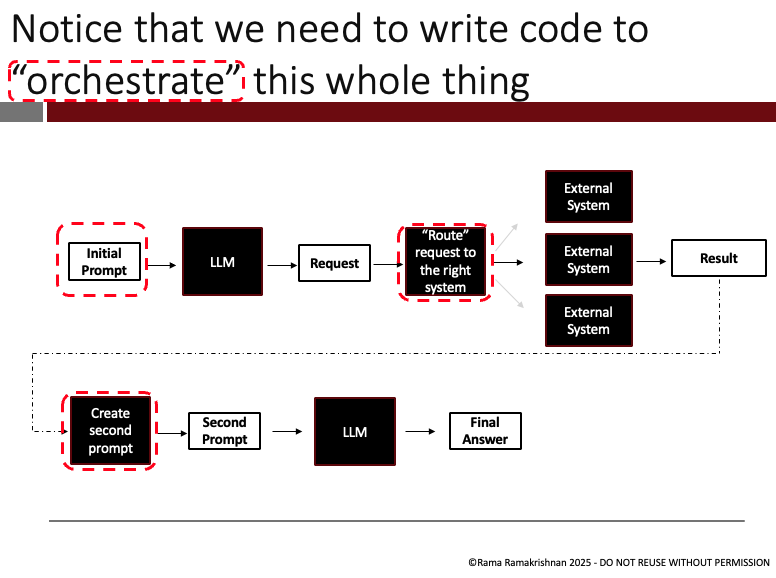

In [ ]:
# a bit later on, we will need to parse the LLM response to see if the word 'Action'
# appears at the start of the response. We will use a regular expression for
# this. If you aren't familiar with this, please copy-paste the two lines
# below into an LLM and ask for an explanation.
import re
action_re = re.compile(r'^Action: (\w+): (.*)$')


# This function will call the LLM, run a function, call the LLM again
# with the results and so on, till we either figure out the answer or
# run out of "turns"

def ask_the_agent(question, max_turns=5):
    i = 0

    # this list will contain the entire conversation
    # between the user and the LLM
    messages = []

    # we will first put in the long prompt from above
    # as the "system prompt" so that it is part of every
    # question
    messages.append({"role": "system", "content": system_prompt})


    # we start with the opening question from the user
    next_prompt = question

    while i < max_turns:  # we allow the conversation to have 5 turns
        i += 1

        # we send the conversation-so-far to the LLM and get the response
        messages.append({"role": "user", "content": next_prompt})
        completion = client.chat.completions.create(model=GPT_MODEL,
                                            messages=messages,
                                            temperature=0)
        result = completion.choices[0].message.content
        messages.append({"role": "assistant", "content": result})
        print(result)


        # we parse the response to see if the word 'Action' appears at the start
        # of the response
        actions = [action_re.match(a) for a in result.split('\n') if action_re.match(a)]

        if actions: # if it does ...

            # we identify which function to call and its inputs
            # we identify which function to call and its inputs
            action, action_input = actions[0].groups()

            # if the LLM responds with an action that is not on our
            # list of available functions, we say "sorry"
            if action not in available_functions:
                raise Exception("Unknown function: {}: {}".format(action, action_input))

            # otherwise, we print out what function we are going to run ...
            print(" -- running {} {}".format(action, action_input))

            # ... and then actually run it
            observation = available_functions[action](action_input)

            # we print out the result of running the function ...
            print("Observation:", observation, "\n")

            # ... and make that the next prompt
            next_prompt = "Observation: {}".format(observation)
        else:
            return

OK, now are all set to test the Agent out.

To clearly demonstrate agentic behavior, we will first pose a question to the model using the `ask_the_LLM` function below. We will then pose the same question to the Agent. Pay attention to how the responses differ.

In [ ]:
# copy-pasted from the Lecture 10 "How to use the LLM API" colab

def ask_the_LLM(prompt,
                model=GPT_MODEL,
                temperature=0):

    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "system",
                   "content": "You are a helpful assistant."},
                  {"role": "user", "content": prompt}],
        temperature=temperature
    )
    return response.choices[0].message.content

## Examples

### Example of the agent NOT using tools if it doesn't have to

In [ ]:
ask_the_agent("When was Maggie Smith born?")

Maggie Smith was born on December 28, 1934.


### Example of the agent using web search: Ask about something that happened **after** the model's training cutoff date

In [ ]:
ask_the_LLM("In which year did Maggie Smith breathe her last?")

'As of my latest information up to June 2024, Maggie Smith is still alive.'

In [ ]:
ask_the_agent("In which year did Maggie Smith breathe her last?")

Thought: Maggie Smith is a renowned British actress, and as of my last update in June 2024, she was still alive. I need to verify if there have been any updates regarding her passing since then by checking Wikipedia.

Action: wikipedia: Maggie Smith death
PAUSE
 -- running wikipedia Maggie Smith death
Observation: <span class="searchmatch">Maggie</span> <span class="searchmatch">Smith</span>. <span class="searchmatch">Maggie</span> <span class="searchmatch">Smith</span> at IMDb  <span class="searchmatch">Maggie</span> <span class="searchmatch">Smith</span> at the American Film Institute Catalog <span class="searchmatch">Maggie</span> <span class="searchmatch">Smith</span> at the Internet Broadway Database <span class="searchmatch">Maggie</span> <span class="searchmatch">Smith</span> at

Dame <span class="searchmatch">Maggie</span> <span class="searchmatch">Smith</span> was a British actress who worked in theatre, television and film. She made her professional theatre debut in 1956 play

### Example of the agent using the calculator: Ask a numeric calculation question that LLMs have difficulty with

In [ ]:
ask_the_agent("What is the cube root of 473740284833?")

Thought: I need to calculate the cube root of 473,740,284,833. I will use the calculate function to find the cube root by raising the number to the power of 1/3.
Action: calculate: 473740284833**(1/3)
PAUSE
 -- running calculate 473740284833**(1/3)
Observation: 7795.550194955124 

Answer: The cube root of 473,740,284,833 is approximately 7795.55.


Beautiful!!

### Example of the agent using its knowledge **and** a tool in combination to answer a complex question

We will ask a question that the LLM can't truthfully answer.

In [ ]:
ask_the_LLM("What is the capital of Vermont and what is the weather there?")

"The capital of Vermont is Montpelier. \n\nI currently don't have access to real-time weather data. You can check the current weather in Montpelier, Vermont, by visiting a weather website like Weather.com or using a weather app on your phone. If you'd like, I can help guide you on how to find this information!"

Now, let's ask the agent the same question.

In [ ]:
ask_the_agent("What is the capital of Vermont and what is the weather there?")

Thought: I know that the capital of Vermont is Montpelier. To provide the current weather, I need to find the latitude and longitude of Montpelier and then get the weather for that location.
Montpelier, Vermont is approximately at latitude 44.2601 and longitude -72.5754.
Action: get_weather: 44.2601,-72.5754
PAUSE
 -- running get_weather 44.2601,-72.5754
Observation: Today's high temperature: 61.96369934082031 

Answer: The capital of Vermont is Montpelier. The current high temperature there is approximately 62°F.


Now how the agent first used its "knowledge" to get the latitude and longitude of Montpelier and then used the `get_weather` function. Impressive!

### Example of the agent using **multiple tools** in sequence to answer a complex question




In [ ]:
ask_the_agent("Is the actor who played Iceman in TopGun alive today? If not what is the cube root of the year of his death?")

Thought: The actor who played Iceman in Top Gun is Val Kilmer. I need to check if Val Kilmer is alive as of today. If he is not alive, I will then calculate the cube root of the year of his death. First, I will verify his current status.

Action: wikipedia: Val Kilmer biography
PAUSE
 -- running wikipedia Val Kilmer biography
Observation: <span class="searchmatch">Val</span> Edward <span class="searchmatch">Kilmer</span> (December 31, 1959 – April 1, 2025) was an American actor. Initially a stage actor, he later found fame as a leading man in films in

Times. 27 March 2002. Retrieved 24 April 2018. &quot;<span class="searchmatch">Val</span> <span class="searchmatch">Kilmer</span> <span class="searchmatch">Biography</span>: Film Actor (1959–)&quot;. <span class="searchmatch">Biography</span>.com (FYI / A&amp;E Networks). Archived from the original

Doors and their influence on music and counterculture. The film stars <span class="searchmatch">Val</span> <span class="searchmatch">Kilmer<

Our little agent called several functions in sequence and answered the question correctly!!! 🚀

Let's try another one.



In [ ]:
ask_the_agent("How many years elapsed between the creation of AlphaFold and \
the awarding of the Nobel Prize to Demis Hassabis?")

Thought: I need to find out the year AlphaFold was created and the year Demis Hassabis was awarded the Nobel Prize. Then I can calculate the number of years elapsed between these two events. I will first look up the creation year of AlphaFold and the year Demis Hassabis received the Nobel Prize.

Action: wikipedia: AlphaFold creation year
PAUSE
 -- running wikipedia AlphaFold creation year
Observation: the problem of protein <span class="searchmatch">folding</span> with <span class="searchmatch">AlphaFold</span>, which achieved state of the art records on benchmark tests for protein <span class="searchmatch">folding</span> prediction. In July 2022

the <span class="searchmatch">Year</span> (Top 10) – for <span class="searchmatch">Alpha</span>Go 2020 Breakthrough of the <span class="searchmatch">Year</span> (Top 10) – for <span class="searchmatch">AlphaFold</span> v1 2021 Breakthrough of the <span class="searchmatch">Year</span> (Winner) – for <span class="searchmatch">AlphaFold</span> 

WOW. RESPECT.

## Conclusion

By just defining three functions using basic Python and setting up a prompt carefully, we were able to elicit 'agentic' behavior from GPT-4.1-mini, a model that **predates** the agentic foundation models that are available today.

That said, it is quite easy to ask questions to stump this agent. For a more robust implementation, we would need to use more powerful LLMs (ideally, reasoning LLMs like OpenAI o3) and have more validation checks, fallbacks etc.